# Latent Dirichlet Allocation and Genomic Ancestry

Genomic data offers invaluable insights into human and animal migration patterns and ancestry, making it a powerful tool for reconstructing history of the world populations. In this project we will analyse genotype data that has been collected from individuals across multiple continents using two latent variable technigue: Principal Component Analysis (PCA) and Latent Dirichlet Allocation (LDA). We will see how both methods can inform on geographical location and ancestry of an individual. 

We will perform analysis on human genotype data from the [1000G project](https://www.internationalgenome.org/). There are multiple dataset available on this ressource, and data preparation can take a large amount of time. We will thus start with a table of selected genotypes provided on the [ancestry_viz github page](https://github.com/hagax8/ancestry_viz). The working tables are provided together with the notebook and were obtained by considering a set of 1976 individuals that were analysed in the [1000G project landmark article](https://www.nature.com/articles/nature15393) and filtering sequence variations according to their diversity based on population genetics models (more details are available on the [corresponding ancestry_viz wiki](https://github.com/hagax8/uGTM/wiki/Appendix:-Generate-ancestry-files)). 

The project will be divided into different tasks:
1. Data loading and visualization of the properties of the variations
2. Application of PCA to the genotype matrix 
3. Presentation of the LDA model and application to 1000G data

## 0. What are SNPS and how can they be used for diagnostic?

SNPs (Single Nucleotide Polymorphisms) are variations at specific DNA positions where a single nucleotide differs among individuals, serving as important genetic markers for researching human diversity and disease associations.

Some SNPs that directly influence a phenotype are known to correlate with geographical ancestry. A famous example is the difference in proportion of the SNPs related to lactose intolerance accross different populations. You can have a look at real data on this subject with this [short tutorial](https://genome.ucsc.edu/training/education/lactase.html). However those cases are rather more the exception than the norm. If one part of genome analysis are concerned the understanding of how a given combination of SNPs can influence characteristics of an individual, a more general question is only concerned how SNP patterns change across populations.

In the following we will be only looking at the changes in SNPs proportion accross different individuals and see how one can use this information to predict the population of an individual. 



## 1. Data loading and visualization

We will be using data from the one thousand genome (1000G) project where individuals from multiple geographic location have been genotyped using a high density genotyping chip. The table is further processed to include only SNPs occuring in a sufficient proportion (more than 2% of the population) and where the proportion of heterozygous alleles follows [Hardy-Weinberg principle](https://en.wikipedia.org/wiki/Hardy%E2%80%93Weinberg_principle) on each chromosome. 

Because the table has been processed we will unfortunately not be able to check if any famous mutation (like the one we just mentionned above about lactose intolerance) is varying in proportion across populations.

Let's proceed with a first short step of data cleaning, followed by an exploratory data analysis on the whole dataset.

In [47]:
## Preparing the modules that will be needed in the following
##
import numpy as np
from numpy import ndarray
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.decomposition import PCA, LatentDirichletAllocation
import matplotlib.pyplot as plt



Note that the matrix of SNPs provided with the notebook is compressed with xz, you can also directly download it 
at [this address](http://lovingscience.com/ancestries/downloads/recoded_1000G.noadmixed.mat)

In [48]:
## We start with populations that are not admixed 
genotypes = pd.read_csv("./recoded_1000G.noadmixed.mat.xz", delimiter = ",",
                        header = None)

print("Size of the genotype matrix:", genotypes.shape)

## The annotation of the genotypes individuals
genotypes_annotation = pd.read_csv("./noAdmixed_1000G_id_labels.csv")


print(genotypes.shape)
print(genotypes_annotation.columns)


Size of the genotype matrix: (1976, 39182)
(1976, 39182)
Index(['id', '1000G population code', 'population',
       '1000G superpopulation code'],
      dtype='object')


In [49]:
# The annotations are in the same order as the genotypes, 
# it's possible to concatenate them when needed

genotype_w_annotation = pd.concat([genotypes, 
                                    genotypes_annotation],
                                    axis = 1)

genotype_w_annotation 

,0,1,2,3,4,5,6,7,8,9,...,39176,39177,39178,39179,39180,39181,id,1000G population code,population,1000G superpopulation code
0,0,0,0,0,1,1,0,0,0,0,...,1,1,0,1,2,1,HG02461,GWD,Gambian in Western Divisions in the Gambia,AFR
1,0,0,0,2,0,2,0,0,0,0,...,1,1,2,2,1,0,HG02462,GWD,Gambian in Western Divisions in the Gambia,AFR
2,0,1,0,2,0,1,0,0,1,0,...,0,1,1,1,1,0,HG02464,GWD,Gambian in Western Divisions in the Gambia,AFR
3,0,2,1,0,0,0,0,1,1,1,...,1,0,0,1,1,0,HG02465,GWD,Gambian in Western Divisions in the Gambia,AFR
4,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,2,HG02561,GWD,Gambian in Western Divisions in the Gambia,AFR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1971,0,0,1,0,2,2,0,1,0,0,...,1,0,0,2,0,0,HG04186,BEB,Bengali from Bangladesh,SAS
1972,0,0,0,0,1,0,1,1,0,0,...,2,1,0,2,1,0,HG04188,BEB,Bengali from Bangladesh,SAS
1973,0,0,0,0,2,1,0,1,0,0,...,0,1,0,1,1,1,HG04189,BEB,Bengali from Bangladesh,SAS
1974,1,0,0,1,1,2,0,1,0,0,...,1,1,0,0,1,0,HG04194,BEB,Bengali from Bangladesh,SAS


### Data cleaning

The data consists of 1976 individuals (rows) and 39,182 SNPs (columns). Recall that human genomes are diploid (two copies of each chromosome) so there are always two alleles for one position. Thus each cell has 3 possible values:
- 0: both allele are the same as the one on the reference genome (`REF`)
- 1: both alleles are the alternative allele (`ALT`)
- 2: We have an heterozygous allele with one ref and one alt  (`HTZ`)

The annotation consists in 4 columns:
- `id`: the individual ID
- `1000G population code`: the 1000G population code (total: 20)
- `population`: The population in a readable form
- `1000G superpopulation code`: a superpopulation code (total: 5)
  - `AFR`: African
  - `AMR`: Admixed American
  - `EAS`: East Asian
  - `EUR`: European
  - `SAS`: South Asian

#### **Questions:**
- First plot an histogram of the proportion of `ALT` and `HTZ` accross indiviuduals and depending on the superpopulation. 
  - Do we observe a difference in the proportion of heterozygous or alternative allele depending on the superpopulation. 
  - How would you explain this effect?
- Like for the regression project, we have to deal with missing data. We will be replacing them with the **median** values observed in for each column. 
  - Report the number of columns with missing data and their counts. 
  - Use the `fillna` method from pandas to replace the missing value by their median.


In [50]:
cols = [i for i in range(0, genotypes.shape[1])]

<Axes: xlabel='HTZ', ylabel='Count'>

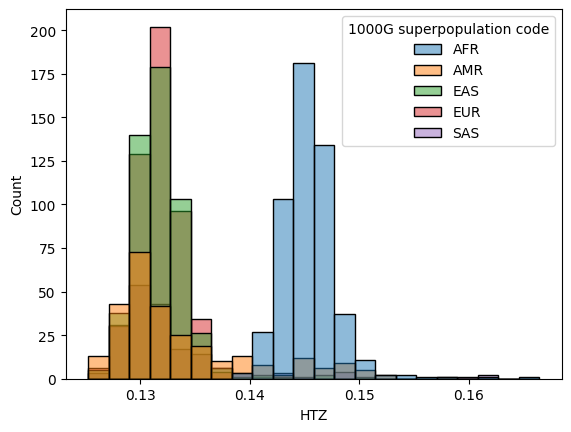

In [51]:

## Compute the proportion of alleles and impute the NAs

## You code here 
geno_prop = genotype_w_annotation
# group by 1000G superpopulation code

geno_prop['HTZ'] = (geno_prop[cols] == 2).mean(axis=1)
### Plotting can be done with the seaborn function

sns.histplot(geno_prop, x= "HTZ", 
             hue = '1000G superpopulation code')


<Axes: xlabel='ALT', ylabel='Count'>

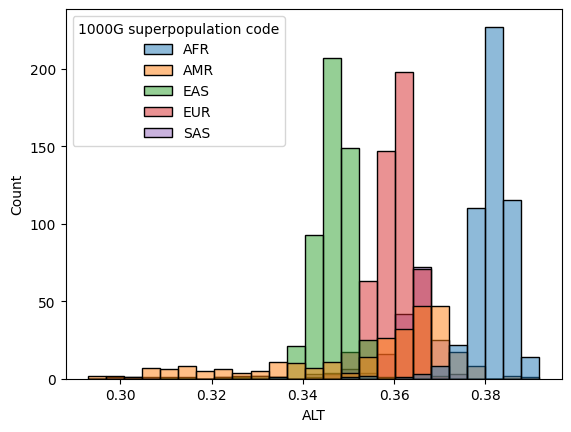

In [52]:
## Compute the proportion of alleles and impute the NAs

## You code here 
geno_prop = genotype_w_annotation
# group by 1000G superpopulation code
cols = [i for i in range(0, genotypes.shape[1])]

geno_prop['ALT'] = (geno_prop[cols] == 1).mean(axis=1)
### Plotting can be done with the seaborn function

sns.histplot(geno_prop, x= "ALT", 
             hue = '1000G superpopulation code')


### Answer
The superpopulations are pretty destinct in the graph. Notably the populations of Africa, East Asia and Europe are quite destinct, with the majority of their samples beeing contained in a small intervall each. Both the plot for ALT and HTZ show, that the population form Africa differs most from the refference. 

In [53]:
genotype_w_annotation[cols].isna().sum(axis=0).sum()

np.int64(2970)

In [54]:
# genotype_w_annotation[cols].median(axis=1)
genotype_w_annotation[cols] = genotype_w_annotation[cols].fillna(genotype_w_annotation[cols].median())

In [55]:
genotype_w_annotation[cols].isna().sum(axis=0).sum()

np.int64(0)

## 2. Applying PCA to the 1000G data

In this task we will be applying PCA to the matrix of SNPs and see how the genotype is dispersed according to the geographical location of the subjects.

To perform the PCA, we will use the `sklearn` environnment. Before applying PCA, it is usually advised to scale it according to the mean and standard deviation (you can use the `sklearn.preprocessing.StandardScaler` method for that). You can then construct a `sklearn.decomposition.PCA` object and apply its `fit` method to obtain principal components and results.

### **Questions:**

- Fit a Principal Component Analysis on the data. Represent the proportion of the variance captured by the principal components as a function of the number of components. 
  - How many components are able to capture most of the linear effects in the data? 
  - What is the cumulative proportion of the variance then explained? 
  - Would you say that PCA is a good dimension reduction technique? 
- Plot the first principal components as pairplots, what do you observe in terms of separation of the superpopulations on the first components? 
- How would you interpret those two observations? 

In [56]:

random_state = 42


X = genotype_w_annotation[cols]

scaler = preprocessing.StandardScaler()
scaler.fit(X)
genotype_w_annotation_trans = genotype_w_annotation.copy()
genotype_w_annotation_trans[cols] = scaler.transform(X)

### Your code here 

In [ ]:
from sklearn.decomposition import PCA

component_numbers = [i for i in range(0,20)] + [i for i in range(20,100, 10)] + [i for i in range(100,1976, 100)] + [1976]
result_component = []


for v in component_numbers:
    pca = PCA(n_components=v)
    results = pca.fit(genotype_w_annotation_trans[cols])
    result_component += [ np.sum(pca.explained_variance_ratio_) ]
    print(f'finshed for value {v}')

finshed for value 0
finshed for value 1
finshed for value 2
finshed for value 3
finshed for value 4
finshed for value 5
finshed for value 6
finshed for value 7
finshed for value 8
finshed for value 9
finshed for value 10
finshed for value 11
finshed for value 12
finshed for value 13
finshed for value 14
finshed for value 15
finshed for value 16
finshed for value 17
finshed for value 18
finshed for value 19
finshed for value 20
finshed for value 30
finshed for value 40
finshed for value 50
finshed for value 60
finshed for value 70
finshed for value 80
finshed for value 90
finshed for value 100
finshed for value 200
finshed for value 300
finshed for value 400
finshed for value 500
finshed for value 600
finshed for value 700
finshed for value 800
finshed for value 900
finshed for value 1000
finshed for value 1100
finshed for value 1200
finshed for value 1300
finshed for value 1400
finshed for value 1500
finshed for value 1600
finshed for value 1700
finshed for value 1800
finshed for value

KeyboardInterrupt: 

In [117]:
# remove me
component_numbers =  component_numbers[:48]
result_component = result_component[:48]

<Axes: >

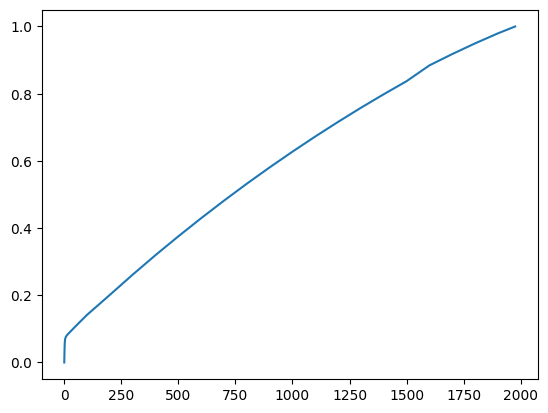

In [118]:
sns.lineplot(x = component_numbers, y= result_component) 

In [ ]:
sns.lineplot(x = component_numbers[:20], y= result_component[:20]) 

### Answer
- How many components are able to capture most of the linear effects in the data? 
- What is the cumulative proportion of the variance then explained? 
- Would you say that PCA is a good dimension reduction technique? 

The graph has a notable kink around 4-7 and rises pretty linearly from there. It semms sensible to use 5 components to represent the model. While these five components still only explain around 10% of the varriance form the original data, the subsequent pairplot shows, that these components are quite good at destinguishing between the superpopulations, separating them clearly form another. So for our purposes PCA is a verry good dimension reduction technique.

In [57]:
# its obvious that the correct parameter is 5️⃣
perfect_parameter = 5
pca = PCA(n_components=perfect_parameter)
results = pca.fit(genotype_w_annotation_trans[cols])

In [58]:
pca_column_names = [f"component_{i}" for i in range(1, perfect_parameter + 1)]
transformed_pcas = pd.DataFrame(columns=pca_column_names)
transformed_pcas[pca_column_names] = pca.transform(genotype_w_annotation_trans[cols])
transformed_pcas_w_annotation = pd.concat([transformed_pcas, 
                                    genotypes_annotation],
                                    axis = 1)

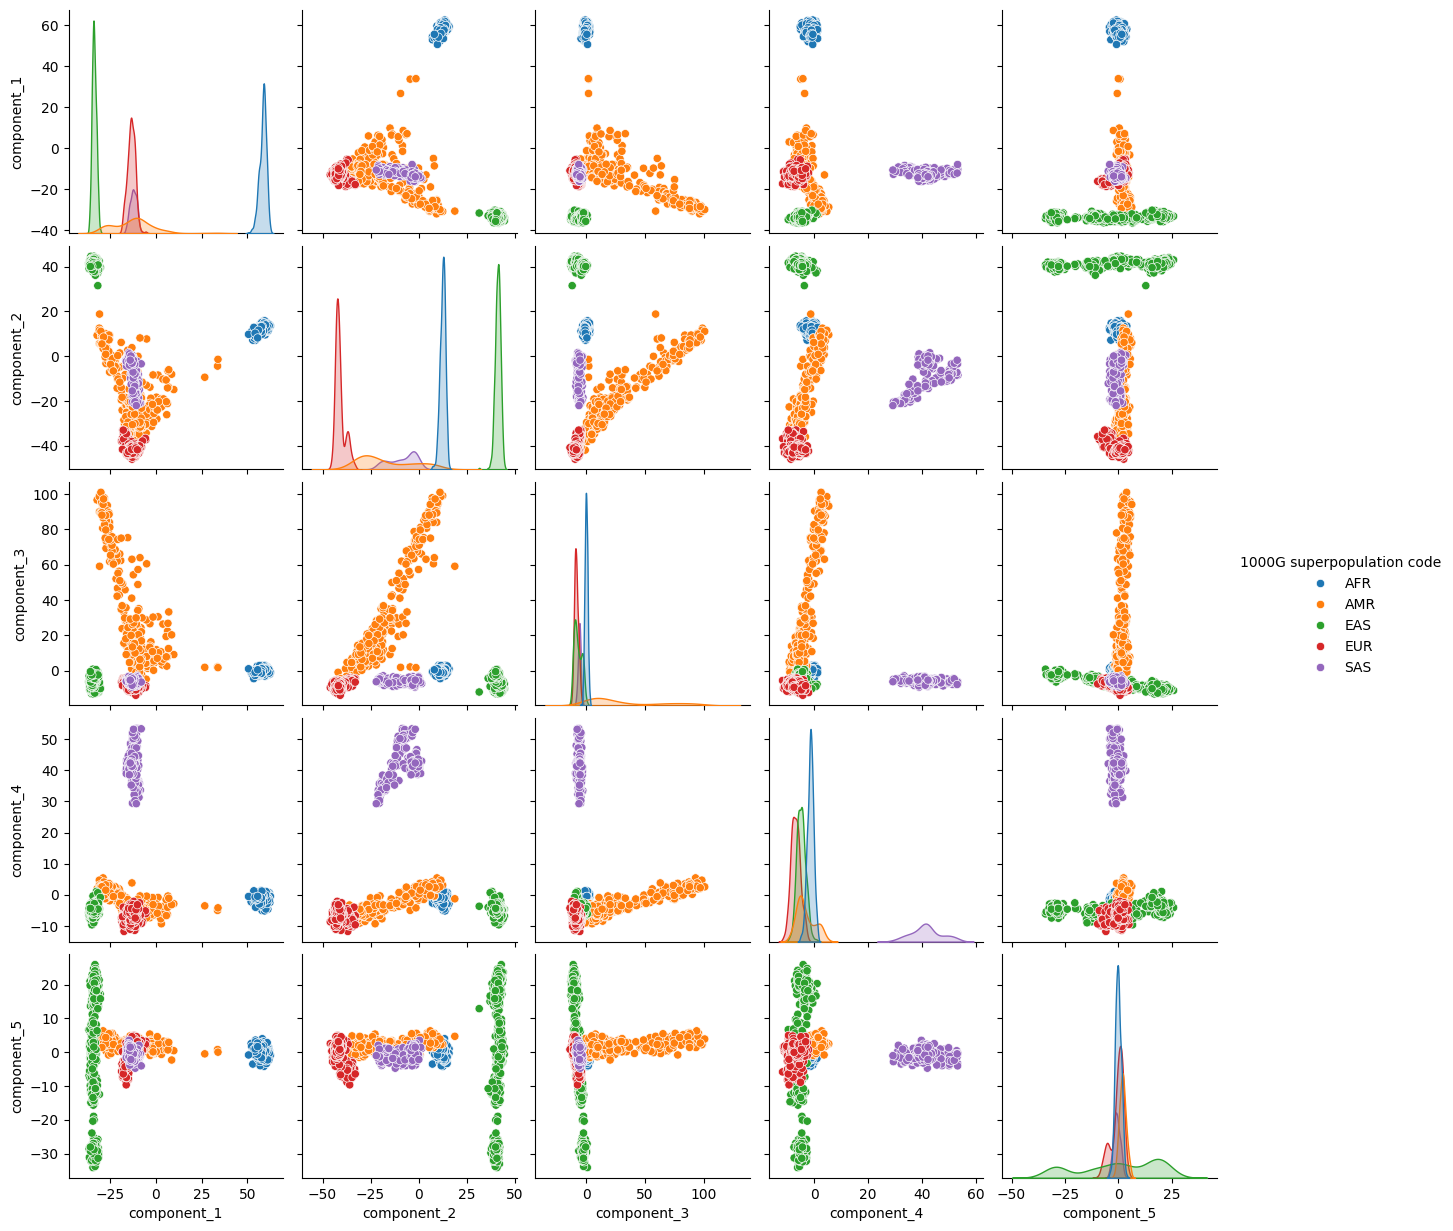

In [59]:
sns.pairplot(
    data=transformed_pcas_w_annotation,
    vars=pca_column_names[:],
    hue="1000G superpopulation code"
)

### Answer

- Plot the first principal components as pairplots, what do you observe in terms of separation of the superpopulations on the first components? 
- How would you interpret those two observations? 

The first two components explain more general variance across all superpopulations. The remaining superpopulations seem to focuses on capturing the varaiance for one superpopulation each and reducing the varriance of the other superpopulations to a single point. Component 3 contains the varriance of the American population, Component 4 that of the South Asian and Component 5 that of the East Asian superpopulation. 



### Using PCA for classification

We see that the PCA projection separates somehow the superpopulation already in the first principal components. We want to test to which accuracy the information of the genotype can be used to predict the superpopulation in a classification framework. We will simply compare a simple k-nearest neighbour classifier based on the euclidian distance of the genotypes, and a classifer using the first components of the PCA.

### **Questions:**
- Separate the dataset into a training and a testing set with a 80% / 20% ratio
- Compare the accuracy for the classification of the superpopulation based on a k-nearest neighbors classifier based on: 
  - the whole genotype vector for each individual
  - the projection of the genotype vector on the 5 first principal components. 


In [60]:
## Prepare train / test in a stratified manner
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

n_folds = 2 
folds = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

X_pca = transformed_pcas_w_annotation[pca_column_names[:5]]
y = transformed_pcas_w_annotation['1000G superpopulation code']
X_gen = genotype_w_annotation_trans[cols]

#random state set -> should have same splitting
pca_split = folds.split(X_pca, y)
gen_split = folds.split(X_gen, y)




In [61]:
pca_scores = []
for train_idx, val_idx in pca_split:
    X_train, X_test = X_pca.iloc[train_idx], X_pca.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    model = KNeighborsClassifier(
        n_neighbors=5,
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    pca_scores.append(accuracy_score(y_test, predictions))
print(pca_scores)

[0.9989878542510121, 0.9959514170040485]


In [62]:
gen_scores = []
for train_idx, val_idx in gen_split:
    X_train, X_test = X_gen.iloc[train_idx], X_gen.iloc[val_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

    model = KNeighborsClassifier(
        n_neighbors=5,
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    gen_scores.append(accuracy_score(y_test, predictions))
print(gen_scores)

[0.979757085020243, 0.9858299595141701]


While both models have a pretty high accuracy, the accuracy of the second model on the pca data is considerably higher. This might be, because the varriance that is lost when reducing the dimensionality of the data is mostly noise. The pairplot shows pretty well, that the principal components are pretty good at separating the different superpopulations.

## 3. Applying Latent Dirichlet Allocation 


### Notations

We simply define as a reminder here the LDA model for document classification. We will be then using an `sklearn` method to estimate it on the 1000G project collection of genotypes. 

Let's remind the notations and the parameters of the model. The vocabulary is of size $V$, and we have $N$ documents of size $L_i$ each. 
We work with the $N\times V$ matrix $C$ or number of occurrence for each word in each document. 
Then the parameters of an LDA model with $K$ topics are:
$$
\begin{align*}
\Theta                   & = (\alpha, \gamma, \mathbf{B}, \pi, \mathbf{q})\\
\pi_i \mid \alpha        & \sim \text{Dir}(\alpha \bullet\mathbf{1}_K)\\
q_{i,l} \mid \pi_i          & \sim \text{Cat}(\pi_{i}[1], \ldots, \pi_i[K]) \\
\mathbf{b}_k \mid \gamma & \sim \text{Dir}(\gamma \bullet \mathbf{1}_K)\\
y_{i,l} \mid q_{i,l} = k, \mathbf{B} & \sim \text{Cat}(b_{k}[1], \ldots, b_{k}[V])
\end{align*}
$$

Note that the sufficient statistic (the only observation needed) to learn the model is the count matrix $C$, as was the case previously. To estimate words per topics probabilities $\mathbf{b}_k$ we only need to obtain an annotated 3D count matrix $N = n_{i,k,v}$ that counts the number of time word $v$ is assigned to topic $k$ in document $i$ (note that the position in the sequence doesn't play a role anymore). From there the point estimators can be obtained by marginalising:
$$
\begin{align*}
b_{k}[v] & = \frac{\sum_{i=1}^{N} n_{i,k, v}}{\sum_{i=i}^{N} \sum_{v=1}^{V} n_{i,k,v}}\\
\pi_i[k] & = \frac{\sum_{v=1}^{V} n_{i,k, v}} {\sum_{v=1}^{V}\sum_{k=1}^{K} n_{i,k,v}}
\end{align*}
$$



### Data encoding

We will now get back to our 1000G project genotypes and apply the LDA model to it. The main question we will need to address are:
- How many population should we use? 
- How to use the results in an easy way?

But first we need to adapt the genotype data to the topic model as we specified it. 

In this case, each  genotype position corresponds to a work $v$ and the ALT is occuring with a certain proportion $b_{k}[v]$ in the topic (*e.g.* population) $k$. 

We thus have to count in principle $2$ occurrences for an `ALT` allele and $1$ occurrence for a `HTZ` one.

We consider each SNP as being a different case, however if we have a 2 we should count the word as occurring twice, and thus we will be counting differently :
- Alternative alleles with a count of 1
- Heterozygous alleles with a count of 0.5

### Question 

Write a short function to reencode the matrix of all genotypes as a bag of words dataset that can  where each SNP is a word in the vocabulary and it's occurrence is given

In [91]:
genotype_w_annotation[cols]

,0,1,2,3,4,5,6,7,8,9,...,39172,39173,39174,39175,39176,39177,39178,39179,39180,39181
0,0,0,0,0,1,1,0,0,0,0,...,0,1,1,1,1,1,0,1,2,1
1,0,0,0,2,0,2,0,0,0,0,...,1,0,1,1,1,1,2,2,1,0
2,0,1,0,2,0,1,0,0,1,0,...,0,0,2,1,0,1,1,1,1,0
3,0,2,1,0,0,0,0,1,1,1,...,0,0,2,1,1,0,0,1,1,0
4,0,0,0,0,0,0,0,1,0,0,...,1,0,2,2,1,1,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1971,0,0,1,0,2,2,0,1,0,0,...,0,0,1,0,1,0,0,2,0,0
1972,0,0,0,0,1,0,1,1,0,0,...,0,0,1,2,2,1,0,2,1,0
1973,0,0,0,0,2,1,0,1,0,0,...,0,0,1,1,0,1,0,1,1,1
1974,1,0,0,1,1,2,0,1,0,0,...,0,2,0,2,1,1,0,0,1,0


In [92]:
## You can work with a sparse matrix of the genotypes constructed with
## scipy, this way the code will run faster later
from scipy.sparse import csr_matrix

## The data matrix can be specified as a csr_matrix
import numpy as np

def genotypes_to_count(G):
    G = np.asarray(G, dtype=float)
    C = G / 2.0
    return csr_matrix(C)

compressed_matrix = genotypes_to_count(genotype_w_annotation[cols])

### Applying the LDA model to the genotype data

We now apply the LDA model with a different number of topics and monitor how well the model fits the data, but using measures such as perplexity and likelihood to assess the fit of the model. 

### **Questions:**
- Run the LDA estimation for an increasing number of topics, starting with 3 topics. You can compute the approximate perplexity or the log-likelihood as a measure of model fit. An example object is defined below to help you specify some of the parameters.
- For a number of topics from 3 to 6, represent the proportion of each topic that was estimated for each individual. You can get inspiration from the figure 1 presented in [this publication](https://rosenberglab.stanford.edu/papers/popstruct.pdf).  
  - Does the LDA model recovers some of the geographical locations the genomes were sampled from? 
  - What other comments can you make about the data? 
  - Are all the populations with the same kind of topic composition? 
- The 1000G project also genotyped populations that are known to present higher level of admixture. Consider the LDA model with 6 topics estimated at the previous question and apply it to the matrix genotypes obtained from the population of mexican ancestry (matrix `recoded_1000G_MXL.mat.xz` that can be also downloaded [here](http://lovingscience.com/ancestries/downloads/recoded_1000G_MXL.mat)). What do you observe? 

*Note:* You can use the `transform` method from the `LatentDirichletAllocation` class to estimate topic proportions for each individual using the data matrix.

In [93]:
from sklearn.decomposition import LatentDirichletAllocation
from time import time

## Example on how to specify the LDA model 

loglik = []
perplexity = []
lda_models = {}
Ks = [i for i in range(3,7)]

for K in Ks:

    lda_5pop = LatentDirichletAllocation(
        n_components=K,
        max_iter=20, # 40 iteration should ensure convergence, but you can try lower values.
        # learning_method="batch", ## 'online' method is recommended if the matrix doesn't fit in memory
        learning_offset=50.0, ##Used in the case of the online training
        random_state=42,
        # changed
        batch_size=1024,
        learning_decay=0.7,
        evaluate_every=1,
        learning_method="online",
        n_jobs= -1 #change that if multiple cores are available
    )

    lda_5pop.fit(compressed_matrix)
    loglik.append(lda_5pop.score(compressed_matrix))
    perplexity.append(lda_5pop.perplexity(compressed_matrix))
    lda_models[K] = lda_5pop
    print(f'finished {K}', K)
## Note that estimation can take up to 10 min per model.



finished 3 3
finished 4 4
finished 5 5
finished 6 6


In [94]:
lda_models

{3: LatentDirichletAllocation(batch_size=1024, evaluate_every=1,
                           learning_method='online', learning_offset=50.0,
                           max_iter=20, n_components=3, n_jobs=-1,
                           random_state=42),
 4: LatentDirichletAllocation(batch_size=1024, evaluate_every=1,
                           learning_method='online', learning_offset=50.0,
                           max_iter=20, n_components=4, n_jobs=-1,
                           random_state=42),
 5: LatentDirichletAllocation(batch_size=1024, evaluate_every=1,
                           learning_method='online', learning_offset=50.0,
                           max_iter=20, n_components=5, n_jobs=-1,
                           random_state=42),
 6: LatentDirichletAllocation(batch_size=1024, evaluate_every=1,
                           learning_method='online', learning_offset=50.0,
                           max_iter=20, n_components=6, n_jobs=-1,
                           random_sta

In [95]:
lda_5pop.perplexity(compressed_matrix)

np.float64(32987.219602025034)

In [96]:
result = lda_5pop.transform(compressed_matrix)

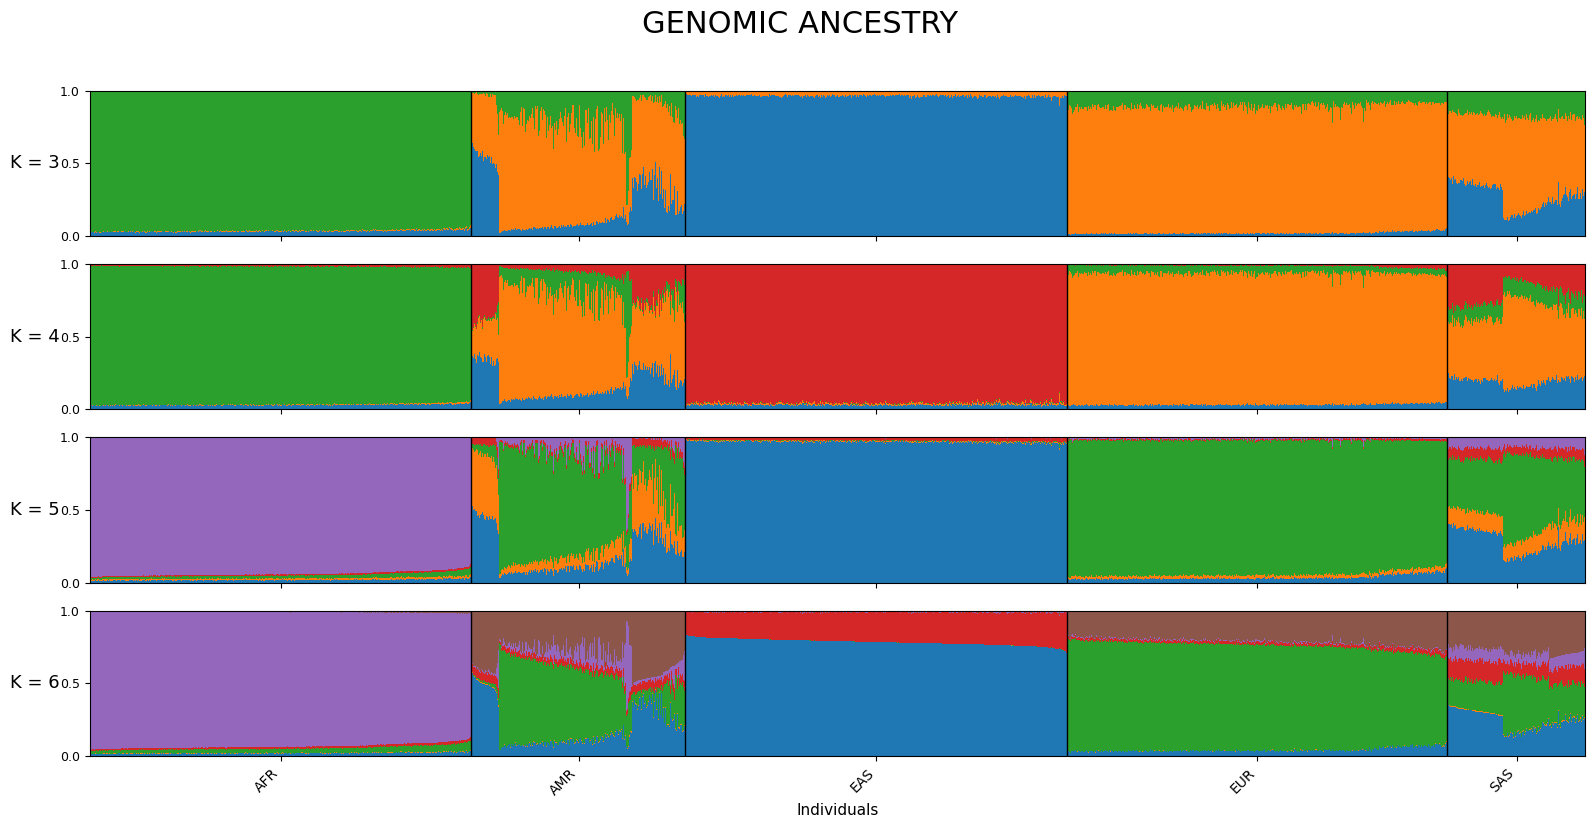

In [97]:
import numpy as np
import matplotlib.pyplot as plt

def plot_genomic_ancestry(lda_models, X, pop_labels, 
                          sort_within_group=True,
                          title="GENOMIC ANCESTRY"):
    """
    STRUCTURE-style stacked barplots for multiple K using fitted sklearn LDA models.

    Parameters
    ----------
    lda_models : dict[int, LatentDirichletAllocation]
        Dictionary mapping K -> fitted LDA model.
    X : array-like or scipy.sparse matrix, shape (n_samples, n_snps)
        Genotype bag-of-words matrix used for LDA.
    pop_labels : array-like of shape (n_samples,)
        Population / group label for each individual (e.g., "Yoruba", "French", ...).
    Ks : list[int] or None
        Which K values to plot. Default = sorted(lda_models.keys()).
    sort_within_group : bool
        If True, sort individuals within each population by their dominant topic proportion.
    title : str
        Figure title.
    """
    pop_labels = np.asarray(pop_labels)

    Ks = sorted(lda_models.keys())

    unique_pops = np.unique(pop_labels)
    idx_order = []
    group_bounds = []  # (start, end, popname)
    start = 0

    # We'll build per-K order later if sorting within group by dominant topic,
    # but keep group contiguity fixed by pop label order.
    pop_to_indices = {p: np.where(pop_labels == p)[0] for p in unique_pops}

    # Precompute Q for each K
    Qs = {}
    for K in Ks:
        Q = lda_models[K].transform(X)  # (n_samples, K), rows sum to 1
        Qs[K] = Q

    # Determine final index order:
    for p in unique_pops:
        inds = pop_to_indices[p]

        if sort_within_group:
            # Use the *largest K* available for within-group sorting stability,
            # so ordering doesn't jump too much across panels.
            Kref = max(Ks)
            qref = Qs[Kref][inds]
            dom = np.argmax(qref, axis=1)
            dom_strength = np.max(qref, axis=1)
            # sort by (dominant topic, then strength) for a STRUCTURE-like look
            local_order = np.lexsort(( -dom_strength, dom ))
            inds = inds[local_order]

        idx_order.extend(inds.tolist())
        end = start + len(inds)
        group_bounds.append((start, end, str(p)))
        start = end

    idx_order = np.asarray(idx_order, dtype=int)

    # --- Plot ---
    nrows = len(Ks)
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(16, 2.1*nrows), sharex=True)
    if nrows == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=22, y=0.98)

    x = np.arange(X.shape[0])

    for ax, K in zip(axes, Ks):
        Q = Qs[K][idx_order]  # reorder samples consistently across K panels

        bottom = np.zeros(Q.shape[0], dtype=float)
        for k in range(Q.shape[1]):
            ax.bar(x, Q[:, k], bottom=bottom, width=1.0, linewidth=0)
            bottom += Q[:, k]

        ax.set_ylim(0, 1)
        ax.set_ylabel("")
        ax.text(-0.02, 0.5, f"K = {K}", transform=ax.transAxes,
                va="center", ha="right", fontsize=13)

        # Group separators
        for (s, e, _) in group_bounds[:-1]:
            ax.axvline(e - 0.5, color="k", linewidth=1)

        ax.set_yticks([0, 0.5, 1.0])
        ax.tick_params(axis="y", labelsize=9)

    # Bottom axis: population labels at group centers
    centers = [(s + e) / 2 for (s, e, _) in group_bounds]
    labels = [name for (_, _, name) in group_bounds]

    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
    axes[-1].set_xlim(-0.5, X.shape[0] - 0.5)
    axes[-1].set_xlabel("Individuals", fontsize=11)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# --- Usage ---
# X must be your genotype BoW matrix (e.g., compressed_matrix)
# pop_labels must be a vector of population IDs in the same row order as X
# Example:
# plot_genomic_ancestry(lda_models, compressed_matrix, pop_labels, Ks=[2,3,4,5,6])

plot_genomic_ancestry(lda_models, compressed_matrix, genotype_w_annotation['1000G superpopulation code'])


### Answer
- Does the LDA model recovers some of the geographical locations the genomes were sampled from? 
- What other comments can you make about the data? 
- Are all the populations with the same kind of topic composition? 

The model is verry accurate in the allocation of the African, East Asian and Eropean superpopulation. These are consistantly allocated to a single topic each (with a slight loss in accuracy for K=6). The American and South Asian superpopulation are allocated less accuratly. They are allocated much less decisively and the color majority color is not unique to them. This might be because these populations are smaller, but it might also be an inherent feature to these genotypes, as we saw in the dimension reduction part these two populations seem to be less homogenous.

In [99]:
genotypes_mxl = pd.read_csv("./recoded_1000G_MXL.mat.xz", delimiter = ",",
                        header = None)
genotypes_mxl[cols] = genotypes_mxl[cols].fillna(genotypes_mxl[cols].median())

In [100]:
csr_mxl = genotypes_to_count(genotypes_mxl)

In [101]:
genotypes_mxl.isna().sum(axis=0).sum(axis=0)

np.int64(0)

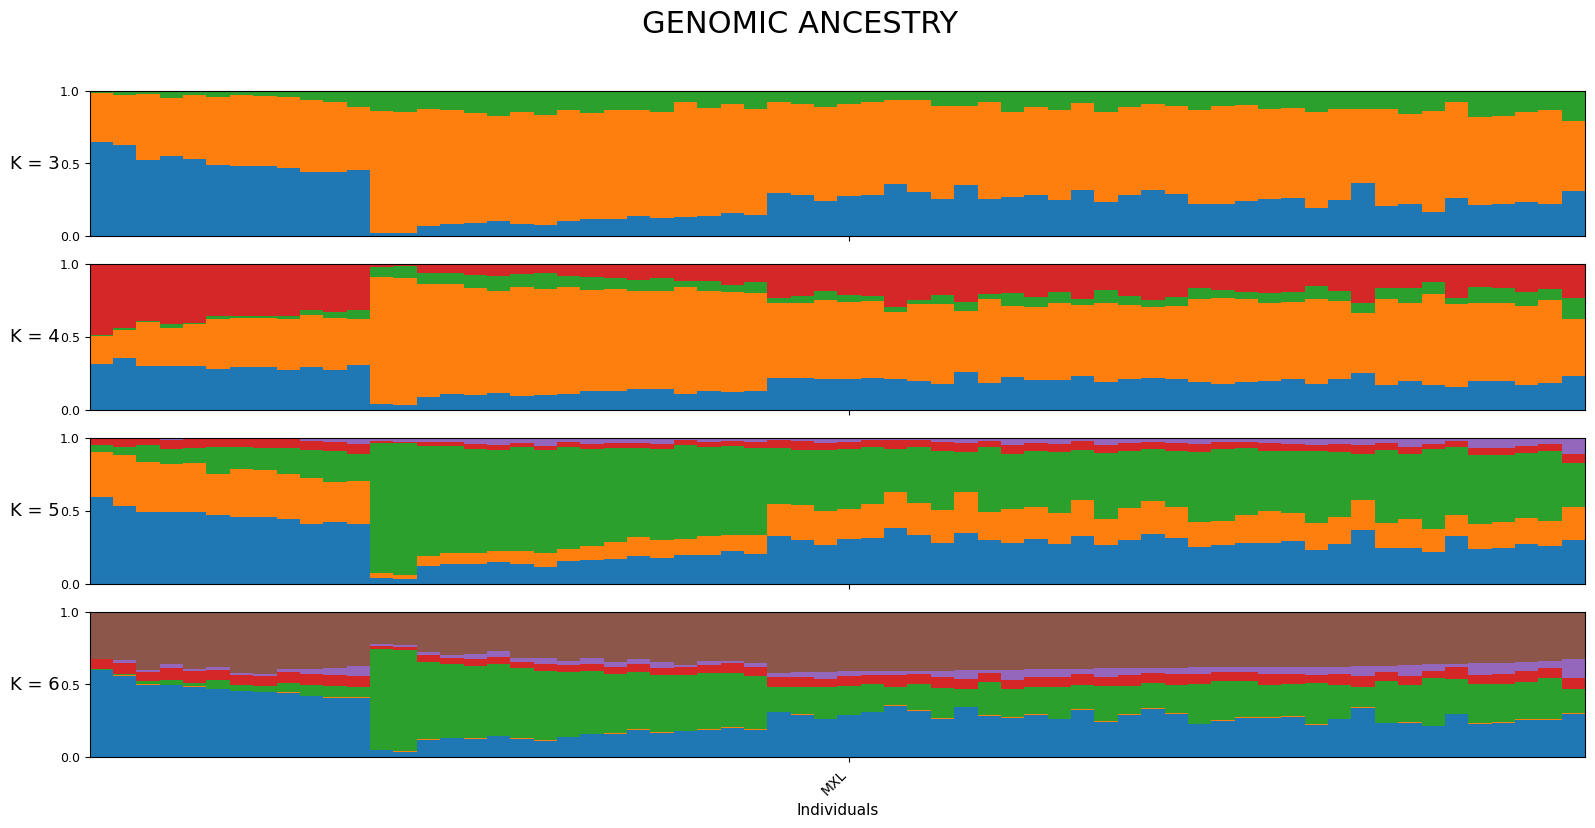

In [103]:
plot_genomic_ancestry(lda_models, csr_mxl, pd.Series(['MXL']* csr_mxl.shape[0]))

### Answer

For all numbers of topics K the allocation probabilities of the samples from the mexican ancesstry set match closely with the allocations of the samples from the American superpopulation. This makes sense, because Mexico is in America. However it is surprising, that this more narrowly defined population is not more homogenic. Instead it seems to have the same spectrum of allocations as the much broader superpopulation. This could hint at the fact, that the model is not verry accurat in depicting American populations compared to the other superpopulations, and that the fact that the model allocates many diffe topics to the American superpopulation is not a reflection the group, but a failing of the model.